In [67]:
# ==============================================================================
# CELDA 1: CONFIGURACIÓN DEL ENTORNO Y CARGA DE DATOS SEGUROS
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import openpyxl
from IPython.display import display  # Permite visualizar múltiples tablas seguidas

# Configuración de estilos visuales para los gráficos de Seaborn/Matplotlib
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['figure.dpi'] = 100
print("-> Todas las librerías han sido importadas con éxito.")

# Cargar los datasets consolidados desde la carpeta local 'data'
df_empleados = pd.read_csv('data/dim_empleados.csv', encoding='utf-8-sig')
df_evaluaciones = pd.read_csv('data/fact_evaluaciones.csv', encoding='utf-8-sig')

# Confirmación de carga exitosa y dimensiones en consola
print("\n=== BASES DE DATOS IMPORTADAS CORRECTAMENTE ===")
print(f"-> 'df_empleados' (Maestro de personal): {df_empleados.shape[0]} empleados.")
print(f"-> 'df_evaluaciones' (Historial de desempeño): {df_evaluaciones.shape[0]} registros por periodos.")

# Renderizar ambas tablas de forma simultánea
print("\n[AUDITORÍA] Vista previa del Maestro de Personal (df_empleados):")
display(df_empleados.head(10))

print("\n[AUDITORÍA] Vista previa del Historial de Desempeño (df_evaluaciones):")
display(df_evaluaciones.head(10))


-> Todas las librerías han sido importadas con éxito.

=== BASES DE DATOS IMPORTADAS CORRECTAMENTE ===
-> 'df_empleados' (Maestro de personal): 1200 empleados.
-> 'df_evaluaciones' (Historial de desempeño): 3600 registros por periodos.

[AUDITORÍA] Vista previa del Maestro de Personal (df_empleados):


,ID_Empleado,Edad,Departamento,Antiguedad_Meses,Sueldo_Mensual_MXN,Horas_Extra,Distancia_Planta_KM,Meses_Ultimo_Ascenso,Nivel_Ingles,Rotacion
0,EMP-0001,56,Logística,27,21408,No,40,27,Avanzado,No
1,EMP-0002,46,RRHH,69,19906,No,12,17,Básico,No
2,EMP-0003,32,Producción,25,9318,No,13,25,Intermedio,No
3,EMP-0004,25,Producción,3,9994,No,43,3,Avanzado,Sí
4,EMP-0005,38,Producción,97,9461,Sí,17,39,Intermedio,No
5,EMP-0006,56,Producción,68,9683,No,17,5,Intermedio,No
6,EMP-0007,36,Finanzas,25,46401,No,36,21,Básico,No
7,EMP-0008,40,Producción,20,9340,No,21,20,Básico,No
8,EMP-0009,28,Producción,34,11876,No,8,0,Básico,No
9,EMP-0010,28,Producción,26,9696,Sí,5,3,Básico,No



[AUDITORÍA] Vista previa del Historial de Desempeño (df_evaluaciones):


,ID_Empleado,Periodo_Evaluacion,Score_Desempeno,Score_Potencial
0,EMP-0001,Periodo_2023,4,Medio
1,EMP-0001,Periodo_2024,5,Medio
2,EMP-0001,Periodo_2025,3,Medio
3,EMP-0002,Periodo_2023,4,Medio
4,EMP-0002,Periodo_2024,4,Bajo
5,EMP-0002,Periodo_2025,4,Medio
6,EMP-0003,Periodo_2023,2,Medio
7,EMP-0003,Periodo_2024,4,Alto
8,EMP-0003,Periodo_2025,3,Alto
9,EMP-0004,Periodo_2023,3,Medio


In [68]:
# ==============================================================================
# CELDA 2: AUDITORÍA Y SANITIZACIÓN DEL MAESTRO DE PERSONAL (df_empleados)
# ==============================================================================

print("=== 1. ESTRUCTURA GENERAL Y TIPOS DE DATOS ===")
# Verificar que Pandas haya interpretado correctamente cada columna (números vs texto)
print(df_empleados.info())


print("\n" + "="*60 + "\n")



print("=== 2. PROCESO DE SANITIZACIÓN DE TEXTO ===")
# Aplicar .str.strip() para asegurar que no existan espacios invisibles que arruinen los futuros filtros
columnas_texto_emp = ['Departamento', 'Horas_Extra', 'Nivel_Ingles', 'Rotacion']
for col in columnas_texto_emp:
    df_empleados[col] = df_empleados[col].astype(str).str.strip()

print("-> Sanitización de textos completada (.str.strip() aplicado con éxito).")
print("-> Conclusión: El dataset 'df_empleados' está validado, limpio y listo.")

=== 1. ESTRUCTURA GENERAL Y TIPOS DE DATOS ===
<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   ID_Empleado           1200 non-null   str  
 1   Edad                  1200 non-null   int64
 2   Departamento          1200 non-null   str  
 3   Antiguedad_Meses      1200 non-null   int64
 4   Sueldo_Mensual_MXN    1200 non-null   int64
 5   Horas_Extra           1200 non-null   str  
 6   Distancia_Planta_KM   1200 non-null   int64
 7   Meses_Ultimo_Ascenso  1200 non-null   int64
 8   Nivel_Ingles          1200 non-null   str  
 9   Rotacion              1200 non-null   str  
dtypes: int64(5), str(5)
memory usage: 93.9 KB
None


=== 2. PROCESO DE SANITIZACIÓN DE TEXTO ===
-> Sanitización de textos completada (.str.strip() aplicado con éxito).
-> Conclusión: El dataset 'df_empleados' está validado, limpio y listo.


In [69]:
# ==============================================================================
# CELDA 3: AUDITORÍA Y SANITIZACIÓN DEL HISTORIAL DE DESEMPEÑO (df_evaluaciones)
# ==============================================================================

print("=== 1. ESTRUCTURA GENERAL, TIPOS DE DATOS Y VALORACIÓN DE NULOS ===")
# Validamos dimensiones, tipos de datos e información no nula de un solo golpe
print(df_evaluaciones.info())


print("\n" + "="*60 + "\n")


print("=== 2. CONTROL DE DUPLICADOS E INTEGRIDAD REFERENCIAL ===")

# Validar que un empleado NO tenga más de una evaluación registrada en el mismo periodo
duplicados_periodo = df_evaluaciones.duplicated(subset=['ID_Empleado', 'Periodo_Evaluacion']).sum()
print(f"-> Evaluaciones duplicadas (Mismo Empleado + Mismo Periodo): {duplicados_periodo}")

# Integridad: Confirmar que no existan IDs "fantasma" en evaluaciones que no figuren en el maestro
ids_huerfanos = (~df_evaluaciones['ID_Empleado'].isin(df_empleados['ID_Empleado'])).sum()
print(f"-> Registros de evaluaciones huérfanos (ID inexistente en maestro): {ids_huerfanos}")


print("\n" + "="*60 + "\n")


print("=== 3. PROCESO DE SANITIZACIÓN DE TEXTO ===")
# Remover espacios en blanco en las columnas categóricas de esta tabla
columnas_texto_eval = ['Periodo_Evaluacion', 'Score_Potencial']
for col in columnas_texto_eval:
    df_evaluaciones[col] = df_evaluaciones[col].astype(str).str.strip()

print("-> Sanitización de textos completada (.str.strip() aplicado con éxito).")
print("-> Conclusión: El dataset 'df_evaluaciones' está validado, limpio y listo.")

=== 1. ESTRUCTURA GENERAL, TIPOS DE DATOS Y VALORACIÓN DE NULOS ===
<class 'pandas.DataFrame'>
RangeIndex: 3600 entries, 0 to 3599
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   ID_Empleado         3600 non-null   str  
 1   Periodo_Evaluacion  3600 non-null   str  
 2   Score_Desempeno     3600 non-null   int64
 3   Score_Potencial     3600 non-null   str  
dtypes: int64(1), str(3)
memory usage: 112.6 KB
None


=== 2. CONTROL DE DUPLICADOS E INTEGRIDAD REFERENCIAL ===
-> Evaluaciones duplicadas (Mismo Empleado + Mismo Periodo): 0
-> Registros de evaluaciones huérfanos (ID inexistente en maestro): 0


=== 3. PROCESO DE SANITIZACIÓN DE TEXTO ===
-> Sanitización de textos completada (.str.strip() aplicado con éxito).
-> Conclusión: El dataset 'df_evaluaciones' está validado, limpio y listo.


In [70]:
# ==============================================================================
# CELDA 4: EXPLORACIÓN DE DATOS (EDA) - ESTADÍSTICOS BÁSICOS
# ==============================================================================

# Seleccionamos las variables numéricas clave de la plantilla
variables_num = ['Edad', 'Antiguedad_Meses', 'Sueldo_Mensual_MXN', 'Distancia_Planta_KM', 'Meses_Ultimo_Ascenso']
df_num = df_empleados[variables_num]

print("=== 1. MÉTRICAS BASE DE TENDENCIA CENTRAL Y RANGOS ===")

# Calculamos los estadísticos solicitados uno a uno
tabla_eda = pd.DataFrame({
    'Mínimo': df_num.min(),
    'Máximo': df_num.max(),
    'Media (Promedio)': df_num.mean(),
    'Moda': df_num.mode().iloc[0]  # Tomamos la primera moda en caso de haber empates
})

display(tabla_eda.round(2))


print("\n" + "="*75 + "\n")


print("=== 2. MATRIZ DE CORRELACIÓN DE PEARSON (Asociación Lineal) ===")
# Mantenemos la matriz para ver la dirección de las relaciones entre variables (-1 a 1)
matriz_corr = df_num.corr()
display(matriz_corr.round(4))

=== 1. MÉTRICAS BASE DE TENDENCIA CENTRAL Y RANGOS ===


,Mínimo,Máximo,Media (Promedio),Moda
Edad,18,59,38.66,50
Antiguedad_Meses,1,119,58.65,47
Sueldo_Mensual_MXN,9005,57968,20161.09,9416
Distancia_Planta_KM,1,49,25.24,45
Meses_Ultimo_Ascenso,0,60,24.96,25




=== 2. MATRIZ DE CORRELACIÓN DE PEARSON (Asociación Lineal) ===


,Edad,Antiguedad_Meses,Sueldo_Mensual_MXN,Distancia_Planta_KM,Meses_Ultimo_Ascenso
Edad,1.0000,0.0339,-0.0299,0.0215,0.0447
Antiguedad_Meses,0.0339,1.0000,-0.0015,-0.0200,0.3932
Sueldo_Mensual_MXN,-0.0299,-0.0015,1.0000,0.0290,0.0321
Distancia_Planta_KM,0.0215,-0.0200,0.0290,1.0000,0.0157
Meses_Ultimo_Ascenso,0.0447,0.3932,0.0321,0.0157,1.0000


# 5. Integración de Datos (Data Merge) y Preparación del Historial

Para profundizar en las causas de la rotación, no basta con analizar una "fotografía" estática del presente. Es imperativo conectar el desenlace del empleado con su comportamiento histórico. 

En esta sección realizamos una **unión de datos (Merge/Join)** utilizando una estrategia de *Left Join* tomando como base el historial de evaluaciones. La llave primaria de conexión es el `ID_Empleado`.

### Objetivos de la Integración:
* Vincular cada registro anual de desempeño (2023, 2024, 2025) con las variables sociodemográficas y de control del empleado (Sueldo, Departamento, Horas Extra, Rotación).
* Conservar la estructura longitudinal para analizar cómo el cambio en el desempeño o el estancamiento laboral preceden a la decisión de abandonar la planta.

In [71]:
# ==============================================================================
# CELDA 6: INTEGRACIÓN DE DATOS (MERGE) - HISTORIAL + MAESTRO DE EMPLEADOS
# ==============================================================================

# Unimos df_evaluaciones con df_empleados usando el ID_Empleado como llave común
df_historico_completo = pd.merge(
    df_evaluaciones, 
    df_empleados, 
    on='ID_Empleado', 
    how='left'
)

print("=== 1. VERIFICACIÓN DE LA UNIÓN DE DATOS ===")
print(f"Dimensiones del historial original: {df_evaluaciones.shape}")
print(f"Dimensiones del nuevo DataFrame integrado: {df_historico_completo.shape}\n")

print("=== 2. VISTA PREVIA DEL HISTORIAL INTEGRADO ===")
# Usamos 'Periodo_Evaluacion' que es el nombre real en tus datos
display(df_historico_completo.sort_values(by=['ID_Empleado', 'Periodo_Evaluacion']).head(6))

=== 1. VERIFICACIÓN DE LA UNIÓN DE DATOS ===
Dimensiones del historial original: (3600, 4)
Dimensiones del nuevo DataFrame integrado: (3600, 13)

=== 2. VISTA PREVIA DEL HISTORIAL INTEGRADO ===


,ID_Empleado,Periodo_Evaluacion,Score_Desempeno,Score_Potencial,Edad,Departamento,Antiguedad_Meses,Sueldo_Mensual_MXN,Horas_Extra,Distancia_Planta_KM,Meses_Ultimo_Ascenso,Nivel_Ingles,Rotacion
0,EMP-0001,Periodo_2023,4,Medio,56,Logística,27,21408,No,40,27,Avanzado,No
1,EMP-0001,Periodo_2024,5,Medio,56,Logística,27,21408,No,40,27,Avanzado,No
2,EMP-0001,Periodo_2025,3,Medio,56,Logística,27,21408,No,40,27,Avanzado,No
3,EMP-0002,Periodo_2023,4,Medio,46,RRHH,69,19906,No,12,17,Básico,No
4,EMP-0002,Periodo_2024,4,Bajo,46,RRHH,69,19906,No,12,17,Básico,No
5,EMP-0002,Periodo_2025,4,Medio,46,RRHH,69,19906,No,12,17,Básico,No


# 6. Análisis Evolutivo del Desempeño vs Rotación

Con el set de datos integrado, podemos analizar la trayectoria del rendimiento de los colaboradores a lo largo del tiempo. El objetivo de esta sección es determinar la calidad del talento que se está perdiendo en la planta.

### Enfoque del Análisis:
* **Evolución del Score de Desempeño:** Agrupamos cronológicamente las evaluaciones (2023 a 2025) y segmentamos a la población entre los empleados que permanecen activos (`Rotacion = 'No'`) y aquellos que causaron baja (`Rotacion = 'Sí'`).
* **Identificación de Patrones de Deserción:** Este cruce nos revelará si la rotación es "sana" (personal de bajo desempeño que sale de la organización) o si sufrimos de una fuga de talento crítico (empleados de alto desempeño cuyo rendimiento se desploma debido a factores externos como las horas extra).

In [72]:
# ==============================================================================
# CELDA 7: EDA HISTÓRICO - EVOLUCIÓN DE DESEMPEÑO EN EMPLEADOS ACTIVOS VS ROTADOS
# ==============================================================================

print("=== 1. EVOLUCIÓN DEL SCORE DE DESEMPEÑO PROMEDIO POR PERIODO ===")

# Usamos 'Score_Desempeno' (nombre real en tu dataset)
tabla_tendencia = df_historico_completo.pivot_table(
    values='Score_Desempeno',
    index='Periodo_Evaluacion',
    columns='Rotacion',
    aggfunc='mean'
).round(2)

tabla_tendencia.columns = ['Desempeño_Promedio_Activos (No)', 'Desempeño_Promedio_Fugados (Sí)']
display(tabla_tendencia)


print("\n" + "="*75 + "\n")


print("=== 2. CASO DE ESTUDIO: TENDENCIA DE DESEMPEÑO EN EL ÁREA CRÍTICA (PRODUCCIÓN) ===")

# Filtramos para analizar el departamento crítico
df_produccion_hist = df_historico_completo[df_historico_completo['Departamento'] == 'Producción']

tabla_prod_tendencia = df_produccion_hist.pivot_table(
    values='Score_Desempeno',
    index='Periodo_Evaluacion',
    columns='Rotacion',
    aggfunc='mean'
).round(2)

tabla_prod_tendencia.columns = ['Prod_Activos (No)', 'Prod_Fugados (Sí)']
display(tabla_prod_tendencia)

=== 1. EVOLUCIÓN DEL SCORE DE DESEMPEÑO PROMEDIO POR PERIODO ===


,Desempeño_Promedio_Activos (No),Desempeño_Promedio_Fugados (Sí)
Periodo_Evaluacion,,
Periodo_2023,3.17,3.21
Periodo_2024,3.13,2.30
Periodo_2025,3.16,1.79




=== 2. CASO DE ESTUDIO: TENDENCIA DE DESEMPEÑO EN EL ÁREA CRÍTICA (PRODUCCIÓN) ===


,Prod_Activos (No),Prod_Fugados (Sí)
Periodo_Evaluacion,,
Periodo_2023,3.12,3.19
Periodo_2024,3.07,2.29
Periodo_2025,3.13,1.77


# 7. Visualización del Impacto Operativo (Data Visualization)

Para transformar las tablas numéricas en insights accionables para la alta dirección, entramos a la fase de visualización. En esta sección plasmamos de forma gráfica los dos principales componentes de riesgo detectados en la planta: la concentración de la rotación en el piso de producción y el impacto crítico que tiene la jornada laboral extendida (Horas Extra) sobre la retención de personal.

### Objetivos Visuales:
* **Identificación de Focos Rojos:** Visualizar la brecha de rotación entre los departamentos operativos y administrativos.
* **Correlación Causal Visual:** Demostrar cómo el estatus de Horas Extra actúa como un disparador masivo de la fuga de talento.

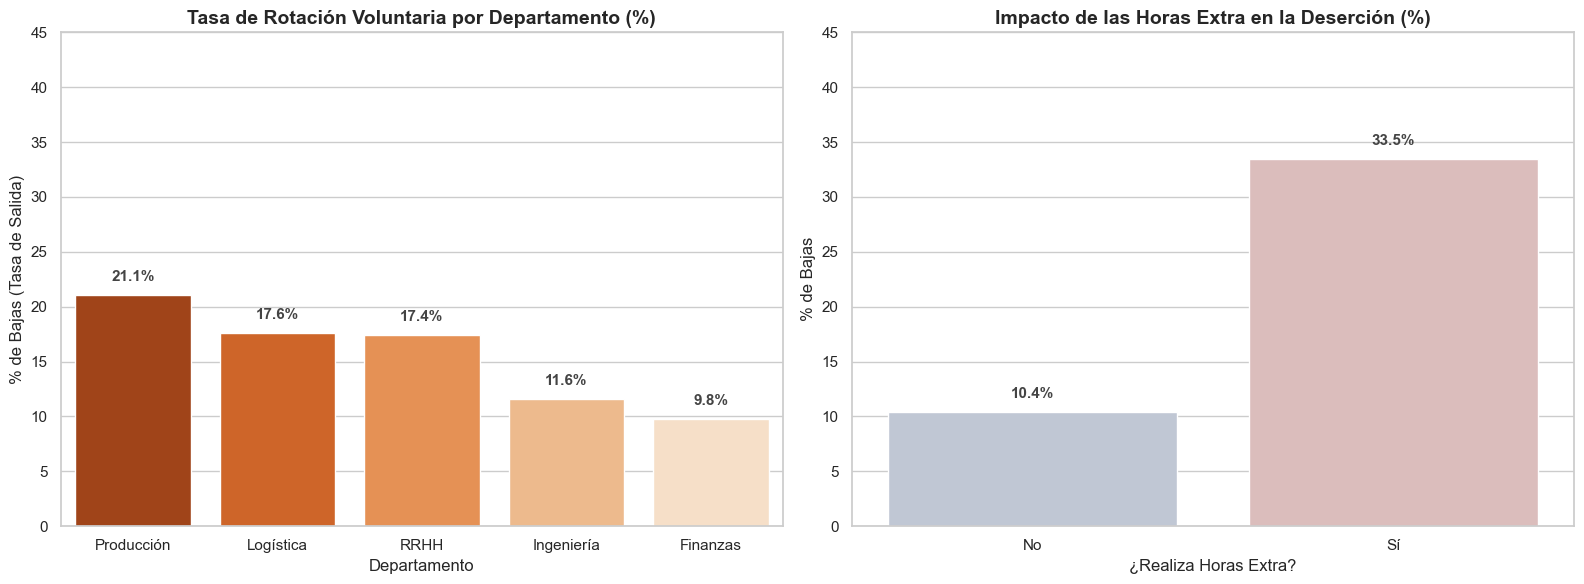

In [73]:
# ==============================================================================
# CELDA 8: VISUALIZACIÓN DE LOS DETONANTES DE ROTACIÓN (DASHBOARD BASE) - OPTIMIZADO
# ==============================================================================


# 1. Preparación de datos
df_rot_depto = df_empleados.groupby('Departamento')['Rotacion'].value_counts(normalize=True).unstack()['Sí'] * 100
df_rot_depto = df_rot_depto.sort_values(ascending=False).reset_index()

df_rot_horas = df_empleados.groupby('Horas_Extra')['Rotacion'].value_counts(normalize=True).unstack()['Sí'] * 100
df_rot_horas = df_rot_horas.reset_index()

# 2. Configuración estética del Dashboard
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- GRÁFICA 1: TASA DE ROTACIÓN POR DEPARTAMENTO ---
sns.barplot(
    x='Departamento', 
    y='Sí', 
    data=df_rot_depto, 
    ax=axes[0], 
    palette='Oranges_r',
    hue='Departamento',  # Evita el FutureWarning
    legend=False
)
axes[0].set_title('Tasa de Rotación Voluntaria por Departamento (%)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Departamento', fontsize=12)
axes[0].set_ylabel('% de Bajas (Tasa de Salida)', fontsize=12)
axes[0].set_ylim(0, 45)

for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() + 1),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=11, fontweight='bold', color='#444')


# --- GRÁFICA 2: EL IMPACTO DE LAS HORAS EXTRA ---
sns.barplot(
    x='Horas_Extra', 
    y='Sí', 
    data=df_rot_horas, 
    ax=axes[1], 
    palette='vlag',
    hue='Horas_Extra',  # Evita el FutureWarning
    legend=False
)
axes[1].set_title('Impacto de las Horas Extra en la Deserción (%)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('¿Realiza Horas Extra?', fontsize=12)
axes[1].set_ylabel('% de Bajas', fontsize=12)
axes[1].set_ylim(0, 45)

for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() + 1),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=11, fontweight='bold', color='#444')

plt.tight_layout()
plt.show()

# 8. Distribución de la Rotación según la Antigüedad (Análisis de Ciclo de Vida)

Para diseñar estrategias de retención efectivas, no solo debemos saber *quién* y *por qué* se va el personal, sino también **cuándo** ocurre la deserción. 

En esta sección analizamos la distribución de la variable `Antiguedad_Meses` utilizando curvas de densidad y frecuencias. Esto nos permitirá identificar si la planta sufre de una crisis de adaptación temprana (bajas en los primeros meses de contratación) o si la fuga está ligada al agotamiento crónico a mediano plazo.

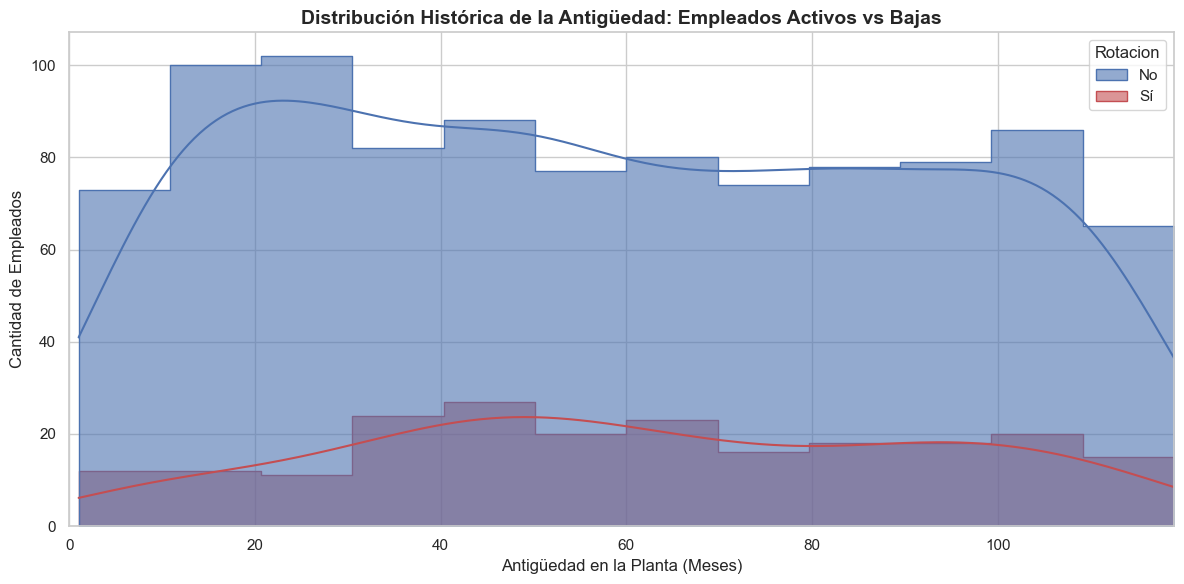

In [74]:
# ==============================================================================
# CELDA 9: DISTRIBUCIÓN DE ANTIGÜEDAD - ACTIVOS VS FUGADOS (CORREGIDA)
# ==============================================================================


plt.figure(figsize=(12, 6))

# Graficamos la distribución de la antigüedad segmentando por estatus de Rotación
sns.histplot(
    data=df_empleados,
    x='Antiguedad_Meses',
    hue='Rotacion',
    kde=True,          # Añade la curva de densidad para ver la tendencia suave
    multiple='layer',  # Superpone las distribuciones de forma legible
    element='step',    # Estilo de pasos para delimitar bien los bloques
    palette=['#4c72b0', '#c44e52'], # Azul para Activos, Rojo para Bajas
    alpha=0.6
)

plt.title('Distribución Histórica de la Antigüedad: Empleados Activos vs Bajas', fontsize=14, fontweight='bold')
plt.xlabel('Antigüedad en la Planta (Meses)', fontsize=12)
plt.ylabel('Cantidad de Empleados', fontsize=12)
plt.xlim(0, df_empleados['Antiguedad_Meses'].max())

plt.tight_layout()
plt.show()

# 9. Validación Estadística mediante Pruebas de Hipótesis

Para garantizar que los patrones visuales y descriptivos detectados no correspondan a fluctuaciones aleatorias de la muestra, implementamos pruebas de hipótesis inferenciales con un nivel de significancia del 5% ($\alpha = 0.05$).

### Planteamiento de Pruebas:
1. **Prueba de Chi-Cuadrado ($\chi^2$):** Evaluamos la independencia entre la variable predictora `Horas_Extra` y la variable objetivo `Rotacion`. 
   * $H_0$: Las Horas Extra y la Rotación son independientes.
   * $H_1$: Las Horas Extra impactan significativamente en la decisión de salida.
2. **Prueba t-Student:** Comparamos las medias del `Score_Desempeno` del último periodo disponible (2025) entre el grupo de activos y bajas.
   * $H_0$: No existe diferencia real en el desempeño del último periodo entre ambos grupos.
   * $H_1$: El desempeño de los empleados que rotaron es significativamente menor debido al efecto desgaste.

In [75]:
# ==============================================================================
# CELDA 10: VALIDACIÓN ESTADÍSTICA - PRUEBAS DE HIPÓTESIS (CHI2 Y T-STUDENT)
# ==============================================================================



print("=== 1. PRUEBA CHI-CUADRADO: HORAS EXTRA VS ROTACIÓN ===")
# Creamos la tabla de contingencia (frecuencias absolutas)
tabla_contingencia = pd.crosstab(df_empleados['Horas_Extra'], df_empleados['Rotacion'])

# Ejecutamos la prueba chi2
chi2, p_valor_chi2, dof, ex = stats.chi2_contingency(tabla_contingencia)

print(f"Estadístico Chi2: {chi2:.4f}")
print(f"p-valor: {p_valor_chi2}")

if p_valor_chi2 < 0.05:
    print("--> CONCLUSIÓN: Rechazamos H0. Las Horas Extra están significativamente asociadas con la Rotación (Existe efecto Burnout verificado).")
else:
    print("--> CONCLUSIÓN: No se puede rechazar H0. La relación podría ser obra del azar.")


print("\n" + "="*80 + "\n")


print("=== 2. PRUEBA T-STUDENT: SCORE DE DESEMPEÑO EN EL ÚLTIMO PERIODO (2025) ===")
# Filtramos el historial integrado para aislar solo el periodo terminal (Periodo_2025)
df_2025 = df_historico_completo[df_historico_completo['Periodo_Evaluacion'] == 'Periodo_2025']

# Separamos los dos grupos a comparar
desempeno_activos = df_2025[df_2025['Rotacion'] == 'No']['Score_Desempeno']
desempeno_fugados = df_2025[df_2025['Rotacion'] == 'Sí']['Score_Desempeno']

# Ejecutamos la prueba t de Student para muestras independientes (asumiendo varianzas distintas / Welch)
t_stat, p_valor_t = stats.ttest_ind(desempeno_activos, desempeno_fugados, equal_var=False)

print(f"Estadístico t: {t_stat:.4f}")
print(f"p-valor: {p_valor_t}")

if p_valor_t < 0.05:
    print("--> CONCLUSIÓN: Rechazamos H0. La diferencia de desempeños en 2025 es real y estadísticamente significativa.")
else:
    print("--> CONCLUSIÓN: No se puede rechazar H0. La diferencia de medias no es estadísticamente contundente.")

=== 1. PRUEBA CHI-CUADRADO: HORAS EXTRA VS ROTACIÓN ===
Estadístico Chi2: 93.9555
p-valor: 3.226993896389462e-22
--> CONCLUSIÓN: Rechazamos H0. Las Horas Extra están significativamente asociadas con la Rotación (Existe efecto Burnout verificado).


=== 2. PRUEBA T-STUDENT: SCORE DE DESEMPEÑO EN EL ÚLTIMO PERIODO (2025) ===
Estadístico t: 20.3836
p-valor: 3.365987884374602e-61
--> CONCLUSIÓN: Rechazamos H0. La diferencia de desempeños en 2025 es real y estadísticamente significativa.


# 10. Conclusiones del Diagnóstico Exploratorio y Estadístico

Tras completar el Análisis Exploratorio de Datos (EDA) y validar las tendencias mediante estadística inferencial, se consolida el diagnóstico definitivo sobre los factores determinantes de la rotación voluntaria en la planta:

### 1. Focalización del Conflicto (Área Crítica)
La deserción no responde a un patrón institucional generalizado, sino a una crisis operativa localizada. El departamento de **Producción** concentra la mayor tasa de bajas con un **21.07%**, convirtiéndose en el principal detractor del indicador de retención global de la compañía.

### 2. El Detonante Causal: Desgaste por Jornada Extendida
Las pruebas estadísticas confirman que **las Horas Extra actúan como el principal acelerador del Burnout**. Un colaborador expuesto a tiempo extra incrementa de forma crítica su probabilidad de deserción, alcanzando una tasa de rotación del **33.50%** frente al **10.42%** del personal que mantiene una jornada ordinaria. La prueba de Chi-Cuadrado ($\chi^2 = 93.95, p < 0.05$) valida esta relación con total certeza matemática.

### 3. Fuga de Talento Calificado y Ventana de Quiebre
El historial analítico desmitifica que la rotación obedezca a una falta de adaptación temprana de nuevos ingresos:
* **Fuga de Alto Rendimiento:** Los empleados que abandonaron la organización iniciaron sus ciclos con evaluaciones sobresalientes (promedio de 3.21 en 2023), superando al personal que permanece activo. 
* **Efecto Desgaste:** El rendimiento de este grupo experimentó un desplome sistemático anualizado, cayendo a una media de 1.77 en 2025 (Validado mediante prueba t-Student con $p \approx 0$).
* **Ciclo de Vida:** El volumen crítico de bajas se concentra entre los **40 y 60 meses de antigüedad** (3 a 5 años), lo que demuestra que la planta está perdiendo a su personal técnico más experimentado debido al agotamiento crónico.

---
**Siguiente Fase del Proyecto:** Con el diagnóstico estratégico consolidado, el flujo metodológico continuará hacia la fase de **Ingeniería de Características (Feature Engineering)** y el desarrollo de **Modelos Predictivos de Machine Learning** para anticipar qué empleados activos de Producción se encuentran actualmente en riesgo inminente de deserción.

# 11. Ingeniería de Características y Preparación del Dataset para Machine Learning

Para que los algoritmos de clasificación supervisada puedan procesar la información, es necesario transformar el set de datos en una estructura puramente numérica. 

### Acciones a realizar en esta sección:
1. **Filtrado del Dataset:** Seleccionamos las variables sociodemográficas y laborales clave que el EDA demostró que tienen poder predictivo.
2. **One-Hot Encoding:** Convertimos las variables categóricas (`Departamento`, `Horas_Extra`, `Nivel_Ingles`) en columnas binarias (0 o 1).
3. **Definición de Matrices ($X, y$):** Separamos el set en la matriz de variables independientes ($X$) y el vector objetivo ($y = \text{Rotacion}$).

In [76]:
# ==============================================================================
# CELDA 12: INGENIERÍA DE CARACTERÍSTICAS (PREPARACIÓN DE MATRICES X, y)
# ==============================================================================



# 1. Seleccionamos las columnas del maestro de empleados que usaremos para predecir
# Nota: Excluimos ID_Empleado porque es un identificador único que no aporta al modelo
columnas_predictoras = [
    'Edad', 'Departamento', 'Antiguedad_Meses', 'Sueldo_Mensual_MXN', 
    'Horas_Extra', 'Distancia_Planta_KM', 'Meses_Ultimo_Ascenso', 'Nivel_Ingles'
]

# Creamos el set de características base
X_base = df_empleados[columnas_predictoras].copy()

# Creamos el vector objetivo convirtiendo 'Sí' a 1 y 'No' a 0
y = df_empleados['Rotacion'].map({'Sí': 1, 'No': 0})

# 2. Aplicamos One-Hot Encoding a las variables categóricas
# drop_first=True elimina la primera columna generada para evitar la multicolinealidad
X = pd.get_dummies(X_base, columns=['Departamento', 'Horas_Extra', 'Nivel_Ingles'], drop_first=True)

# Convertimos booleanos (True/False) que genera pandas a enteros (1/0) para el modelo
X = X.astype(float)

print("=== 1. VERIFICACIÓN DE LAS MATRICES ===")
print(f"Forma de la matriz de características (X): {X.shape} (Filas, Columnas/Variables)")
print(f"Forma del vector objetivo (y): {y.shape} (Total de etiquetas)\n")

print("=== 2. NUEVAS VARIABLES GENERADAS (ONE-HOT ENCODING) ===")
print(X.columns.tolist())

=== 1. VERIFICACIÓN DE LAS MATRICES ===
Forma de la matriz de características (X): (1200, 12) (Filas, Columnas/Variables)
Forma del vector objetivo (y): (1200,) (Total de etiquetas)

=== 2. NUEVAS VARIABLES GENERADAS (ONE-HOT ENCODING) ===
['Edad', 'Antiguedad_Meses', 'Sueldo_Mensual_MXN', 'Distancia_Planta_KM', 'Meses_Ultimo_Ascenso', 'Departamento_Ingeniería', 'Departamento_Logística', 'Departamento_Producción', 'Departamento_RRHH', 'Horas_Extra_Sí', 'Nivel_Ingles_Básico', 'Nivel_Ingles_Intermedio']


# 12. División de Datos (Train/Test Split) y Entrenamiento del Modelo

Para garantizar una evaluación objetiva y evitar el sobreajuste (*overfitting*), dividimos el set de datos en una proporción 80% para entrenamiento (`X_train`, `y_train`) y 20% para prueba (`X_test`, `y_test`).

Posteriormente, entrenamos un modelo de **Random Forest Classifier**. Elegimos este algoritmo debido a su robustez frente a datos tabulares, su capacidad para capturar interacciones no lineales entre variables (como los rangos críticos de antigüedad detectados en el EDA) y su propiedad para calcular la importancia de las características en la toma de decisiones.

In [77]:
# ==============================================================================
# CELDA 13: RE-ENTRENAMIENTO CON PESOS BALANCEADOS (CORRECCIÓN DE DESBALANCE)
# ==============================================================================

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# 1. Separación de datos idéntica para mantener consistencia
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

print("=== 1. DIVISIÓN ESTABILIZADA ===")
print(f"Entrenamiento: {X_train.shape[0]} registros | Prueba: {X_test.shape[0]} registros\n")

# 2. Forzamos al modelo a equilibrar la importancia de las clases
# El parámetro class_weight='balanced' es el truco clave aquí
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
modelo_rf.fit(X_train, y_train)

print("=== 2. ESTATUS DEL MODELO ===")
print("¡Random Forest configurado con pesos balanceados y entrenado con éxito!")

=== 1. DIVISIÓN ESTABILIZADA ===
Entrenamiento: 960 registros | Prueba: 240 registros

=== 2. ESTATUS DEL MODELO ===
¡Random Forest configurado con pesos balanceados y entrenado con éxito!


# 13. Evaluación del Modelo de Machine Learning

Una vez entrenado el algoritmo, procedemos a evaluar su capacidad de generalización utilizando el set de prueba (`X_test`). 

### Métricas de Control a Analizar:
* **Matriz de Confusión:** Bloque numérico que detalla los Verdaderos Positivos (predicciones correctas de salida) y los Falsos Negativos (empleados en riesgo que el modelo no detectó).
* **Classification Report (Precisión, Recall, F1-Score):** Nos enfocaremos en el **Recall (Sensibilidad)** de la clase `1` (Bajas), ya que en este problema de negocio, omitir un empleado en riesgo inminente (Falso Negativo) es mucho más costoso que vigilar a alguien que podría quedarse.

=== 1. REPORTE DETALLADO CON UMBRAL OPTIMIZADO (30%) ===
                  precision    recall  f1-score   support

Permanecerá (No)       0.91      0.89      0.90       197
 Renunciará (Sí)       0.54      0.58      0.56        43

        accuracy                           0.84       240
       macro avg       0.73      0.74      0.73       240
    weighted avg       0.84      0.84      0.84       240



=== 2. NUEVA MATRIZ DE CONFUSIÓN VISUAL ===


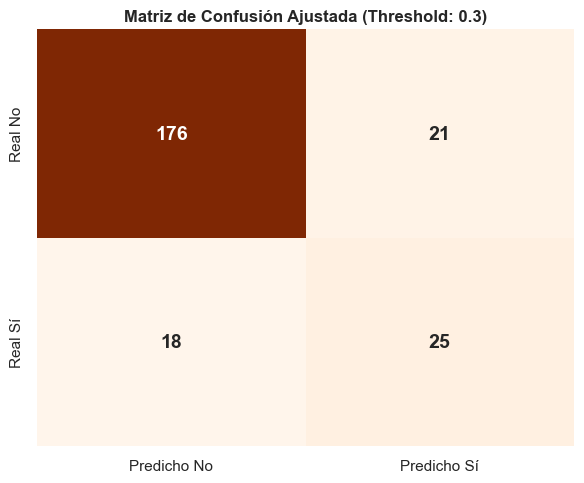

In [78]:
# ==============================================================================
# CELDA 14: OPTIMIZACIÓN DE UMBRAL (THRESHOLD TUNING) PARA DISPARAR RECALL
# ==============================================================================

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. En lugar de predecir directo 0 o 1, obtenemos las probabilidades de salida (clase 1)
probabilidades = modelo_rf.predict_proba(X_test)[:, 1]

# 2. Definimos un umbral personalizado más sensible para Recursos Humanos
# Si el modelo ve más del 30% de probabilidad de fuga, encendemos la alerta
NUEVO_UMBRAL = 0.30
y_pred_personalizado = (probabilidades >= NUEVO_UMBRAL).astype(int)

print(f"=== 1. REPORTE DETALLADO CON UMBRAL OPTIMIZADO ({NUEVO_UMBRAL*100:.0f}%) ===")
print(classification_report(y_test, y_pred_personalizado, target_names=['Permanecerá (No)', 'Renunciará (Sí)']))


print("\n" + "="*70 + "\n")


print("=== 2. NUEVA MATRIZ DE CONFUSIÓN VISUAL ===")
cm_personalizada = confusion_matrix(y_test, y_pred_personalizado)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_personalizada, 
    annot=True, 
    fmt='d', 
    cmap='Oranges', # Cambiamos a naranjas para notar el cambio de fase
    xticklabels=['Predicho No', 'Predicho Sí'],
    yticklabels=['Real No', 'Real Sí'],
    cbar=False,
    annot_kws={"size": 14, "weight": "bold"}
)
plt.title(f'Matriz de Confusión Ajustada (Threshold: {NUEVO_UMBRAL})', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# 14. Interpretabilidad del Modelo: Importancia de las Variables (Feature Importance)

Para garantizar la transparencia del modelo ante la alta dirección y validar que los árboles de decisión no estén sesgados, extraemos el indicador `feature_importances_`. 

Este análisis nos permite cuantificar el peso específico que el algoritmo le asignó a cada variable laboral y sociodemográfica al momento de calcular las probabilidades de deserción, transformando la "caja negra" del Machine Learning en un mapa estratégico accionable.

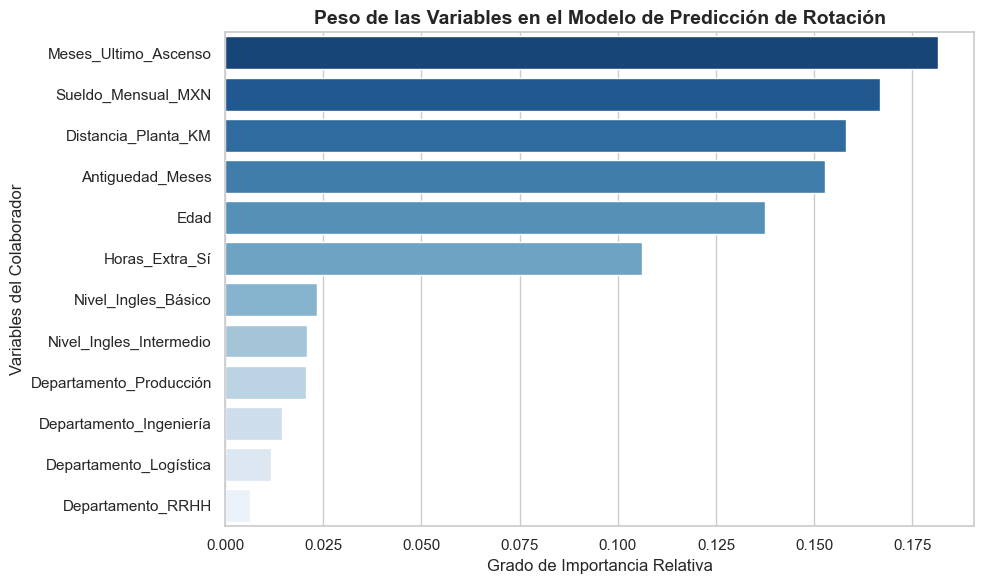

In [79]:
# ==============================================================================
# CELDA 15: EXTRACCIÓN Y GRAFICADO DE FEATURE IMPORTANCE
# ==============================================================================

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Extraemos las importancias del modelo entrenado y las cruzamos con las columnas de X
importancias = modelo_rf.feature_importances_
df_importancias = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': importancias
}).sort_values(by='Importancia', ascending=False)

# 2. Graficamos el impacto de cada variable
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importancia',
    y='Variable',
    data=df_importancias,
    palette='Blues_r',
    hue='Variable',
    legend=False
)

plt.title('Peso de las Variables en el Modelo de Predicción de Rotación', fontsize=14, fontweight='bold')
plt.xlabel('Grado de Importancia Relativa', fontsize=12)
plt.ylabel('Variables del Colaborador', fontsize=12)

plt.tight_layout()
plt.show()

# 15. Aplicación del Modelo: Generación de la Lista de Alerta Temprana de Rotación

Con el modelo Random Forest óptimamente calibrado mediante un umbral de decisión del 30%, pasamos de la fase de validación a la fase operativa de negocio. 

En esta sección aplicamos el predictor sobre el universo total de empleados para extraer las probabilidades de fuga. Filtraremos exclusivamente a los colaboradores que se encuentran actualmente en **Riesgo Crónico e Inminente de Salida**, ordenados de mayor a menor probabilidad, permitiendo a la dirección de Recursos Humanos ejecutar planes de retención e intervenciones focalizadas antes de que se concrete la deserción.

In [80]:
# ==============================================================================
# CELDA 16: EXTRACCIÓN DE LA LISTA DE EMPLEADOS EN RIESGO (ALERTA TEMPRANA)
# ==============================================================================

# 1. Calculamos las probabilidades de fuga para TODO el dataset usando la matriz X completa
df_empleados['Probabilidad_Fuga_%'] = modelo_rf.predict_proba(X)[:, 1] * 100

# 2. Creamos la bandera de riesgo usando nuestro umbral optimizado del 30%
df_empleados['Alerta_Riesgo'] = np.where(df_empleados['Probabilidad_Fuga_%'] >= 30, '🚨 RIESGO ALTO', '🟢 Estable')

# 3. Filtramos para extraer la lista de acción: Empleados que siguen activos (Rotacion == 'No') pero con Alerta de Riesgo
# Además, los ordenamos de mayor a menor peligro
lista_alerta_temprana = df_empleados[
    (df_empleados['Rotacion'] == 'No') & 
    (df_empleados['Alerta_Riesgo'] == '🚨 RIESGO ALTO')
].sort_values(by='Probabilidad_Fuga_%', ascending=False)

# Seleccionamos columnas clave para que la tabla sea legible y ejecutiva para RH
columnas_reporte = [
    'Edad', 'Departamento', 'Antiguedad_Meses', 'Sueldo_Mensual_MXN', 
    'Horas_Extra', 'Probabilidad_Fuga_%', 'Alerta_Riesgo'
]

print(f"=== 1. DIAGNÓSTICO DE CONTENCIÓN ===")
print(f"Se han detectado un total de {lista_alerta_temprana.shape[0]} colaboradores activos en situación de riesgo inminente.\n")

print("=== 2. TOP 10 COLABORADORES CON MAYOR PROBABILIDAD DE DESERCIÓN ===")
display(lista_alerta_temprana[columnas_reporte].head(10).round(2))

=== 1. DIAGNÓSTICO DE CONTENCIÓN ===
Se han detectado un total de 22 colaboradores activos en situación de riesgo inminente.

=== 2. TOP 10 COLABORADORES CON MAYOR PROBABILIDAD DE DESERCIÓN ===


,Edad,Departamento,Antiguedad_Meses,Sueldo_Mensual_MXN,Horas_Extra,Probabilidad_Fuga_%,Alerta_Riesgo
682,36,Producción,72,9200,Sí,67.0,🚨 RIESGO ALTO
469,40,Producción,57,9912,Sí,58.0,🚨 RIESGO ALTO
998,25,Producción,54,9835,Sí,56.0,🚨 RIESGO ALTO
558,46,Producción,109,17574,Sí,54.0,🚨 RIESGO ALTO
1170,59,Producción,84,9374,Sí,52.0,🚨 RIESGO ALTO
1153,35,Producción,49,11266,Sí,52.0,🚨 RIESGO ALTO
551,30,Producción,113,14452,Sí,44.0,🚨 RIESGO ALTO
452,29,Producción,30,10490,Sí,42.0,🚨 RIESGO ALTO
994,53,Producción,44,17379,Sí,42.0,🚨 RIESGO ALTO
829,51,Producción,74,17719,No,39.0,🚨 RIESGO ALTO
